# 🚁 Faster R-CNN - Local Inference & Evaluation

**Model:** Faster R-CNN (MobileNetV3-Large 320 Backbone)  
**Weights:** `fasterrcnn_drone.pth`  
**Device:** Mac M4 (`mps`) or CPU

In [1]:
import torch
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import time
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. Setup Device (Mac Optimized)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Acceleration: Apple MPS (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Acceleration: NVIDIA CUDA")
else:
    device = torch.device("cpu")
    print("⚠️ Acceleration: CPU (Inference might be slower)")

✅ Acceleration: Apple MPS (Metal Performance Shaders)


### 2. Load Model & Configuration

In [2]:
# --- CONFIGURATION ---
weights_path = 'fasterrcnn_drone.pth'
dataset_root = './drone-dataset'  # UPDATE THIS PATH
class_names = ['Airplane', 'Drone', 'Helicopter']

# --- MODEL DEFINITION ---
def get_model(num_classes):
    # Must match the architecture used in training
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

# Load Weights
model = get_model(len(class_names) + 1) # +1 for background class

if os.path.exists(weights_path):
    # map_location ensures it loads on Mac even if trained on Linux GPU
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f"✅ Successfully loaded: {weights_path}")
else:
    print(f"❌ ERROR: Could not find {weights_path}. Check file name/path.")

✅ Successfully loaded: fasterrcnn_drone.pth


### 3. Visual Prediction (6-Image Grid)

🔍 Running inference on 6 random images...


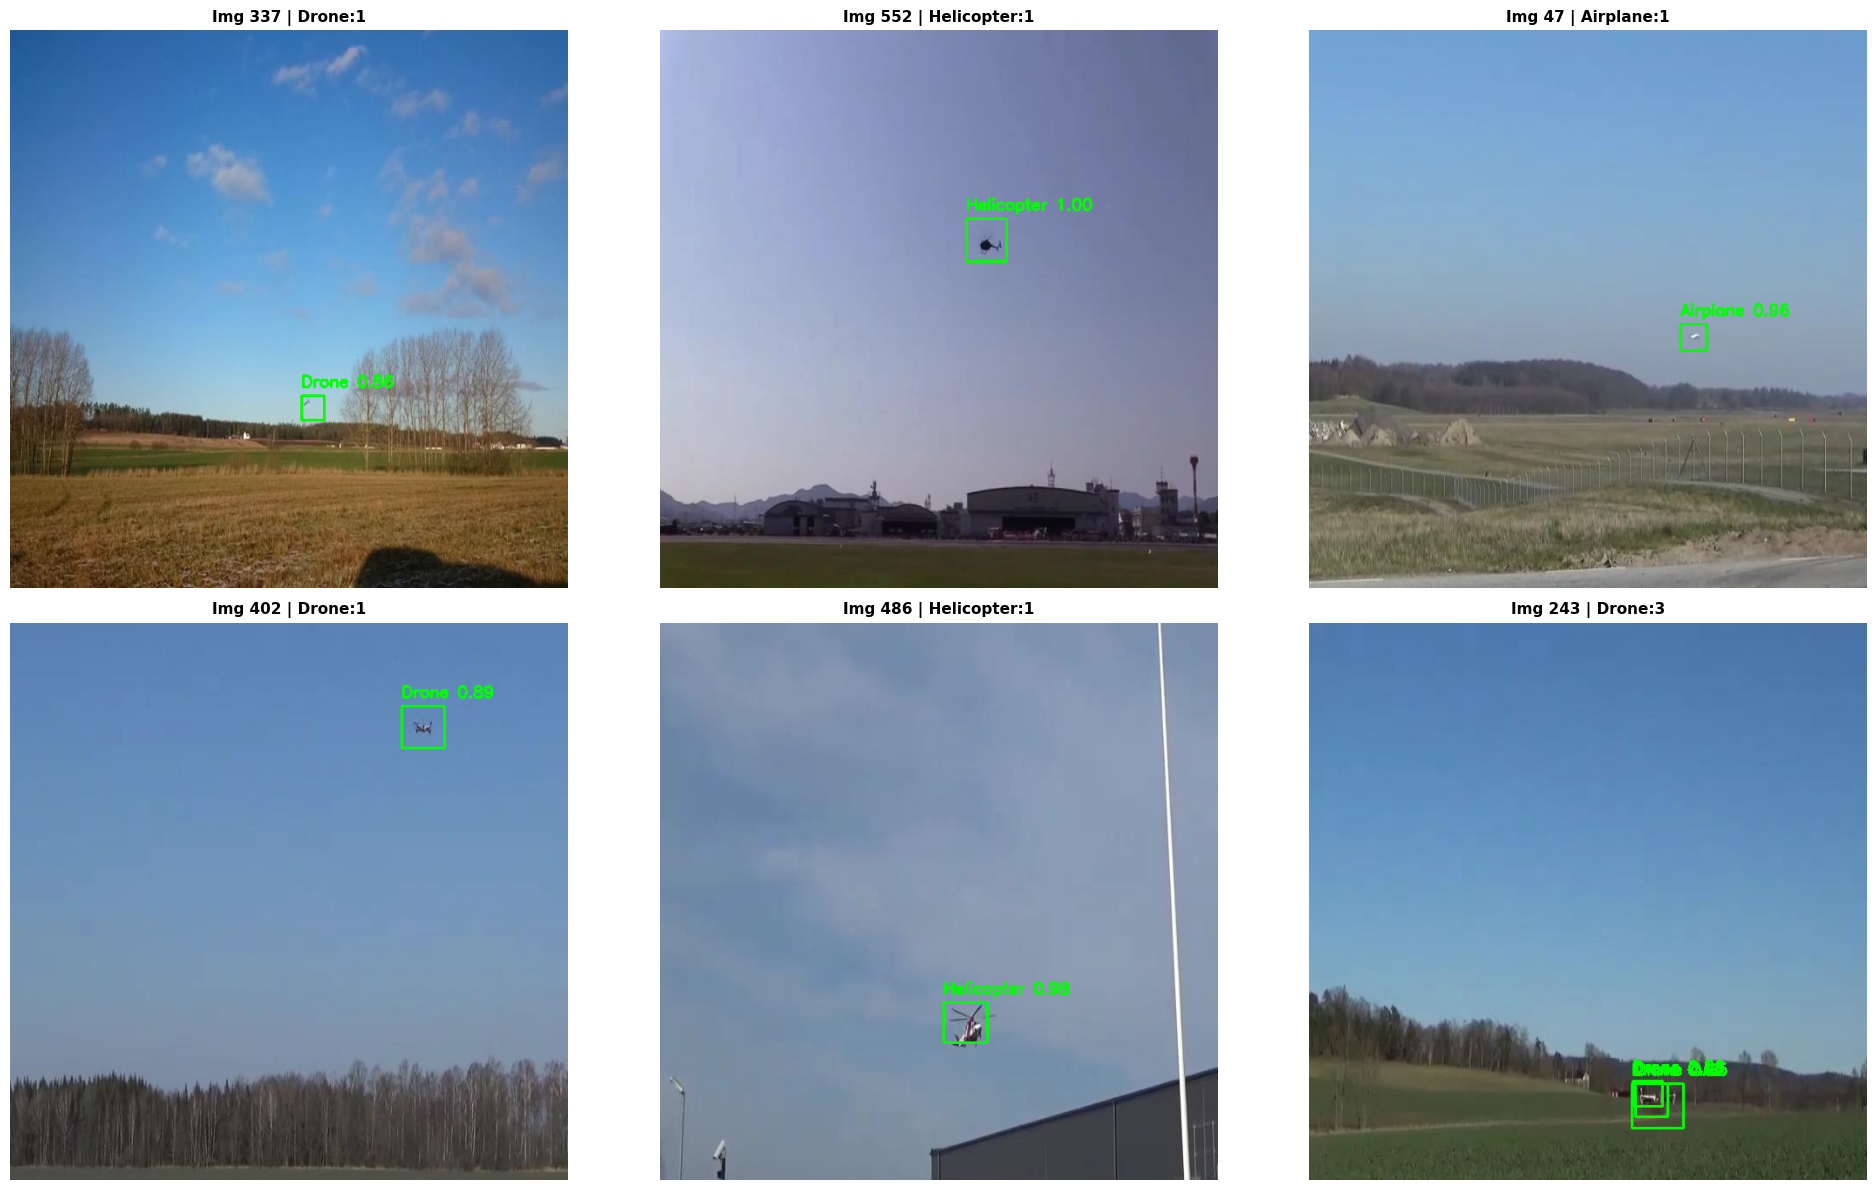

In [6]:
# Simple Dataset Loader (Images Only for Inference)
class LocalImageDataset:
    def __init__(self, root, split='valid'):
        self.imgs_dir = os.path.join(root, split, 'images')
        if not os.path.exists(self.imgs_dir):
             raise FileNotFoundError(f"Directory not found: {self.imgs_dir}")
        self.imgs = sorted([f for f in os.listdir(self.imgs_dir) if f.lower().endswith(('.jpg', '.png'))])
    
    def get_image(self, idx):
        img_path = os.path.join(self.imgs_dir, self.imgs[idx])
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_tensor = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2, 0, 1)
        return img_tensor, img_rgb, img_path
    
    def __len__(self): return len(self.imgs)

try:
    ds = LocalImageDataset(dataset_root, split='valid')
    indices = random.sample(range(len(ds)), 6)
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    print("🔍 Running inference on 6 random images...")
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img_tensor, img_rgb, _ = ds.get_image(idx)
            
            # Inference
            start = time.time()
            prediction = model([img_tensor.to(device)])[0]
            end = time.time()
            
            # Prepare visualization
            img_viz = img_rgb.copy()
            detections = {}
            
            for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
                if score > 0.45: # Threshold
                    x1, y1, x2, y2 = box.cpu().numpy().astype(int)
                    name = class_names[label.item()-1]
                    detections[name] = detections.get(name, 0) + 1
                    
                    # Draw box
                    cv2.rectangle(img_viz, (x1, y1), (x2, y2), (0, 255, 0), 2)
                    label_text = f"{name} {score:.2f}"
                    cv2.putText(img_viz, label_text, (x1, y1-10), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            
            axes[i].imshow(img_viz)
            axes[i].axis('off')
            title_str = ", ".join([f"{k}:{v}" for k,v in detections.items()]) if detections else "No detections"
            axes[i].set_title(f"Img {idx} | {title_str}", fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"⚠️ Error running demo: {e}")
    print("Check your 'dataset_root' path.")

### 4. Model Evaluation (Speed & Confidence Stats)
Runs through 50 random images to calculate FPS and average confidence.

In [7]:
num_test_images = 50
total_time = 0
total_detections = 0
confidences = []

print(f"📊 Evaluating performance on {num_test_images} images...")

try:
    test_indices = random.sample(range(len(ds)), min(num_test_images, len(ds)))
    
    with torch.no_grad():
        for idx in test_indices:
            img_tensor, _, _ = ds.get_image(idx)
            
            # Time Inference
            start = time.time()
            outputs = model([img_tensor.to(device)])
            end = time.time()
            
            total_time += (end - start)
            
            # Gather Stats
            scores = outputs[0]['scores'].cpu().numpy()
            high_conf_scores = scores[scores > 0.5]
            
            total_detections += len(high_conf_scores)
            confidences.extend(high_conf_scores)
            
    avg_time = total_time / len(test_indices)
    fps = 1.0 / avg_time
    avg_conf = sum(confidences) / len(confidences) if confidences else 0.0

    print("\n" + "="*30)
    print(f"🚀 Performance Metrics ({device})")
    print("="*30)
    print(f"⏱️  Avg Inference Time: {avg_time*1000:.1f} ms")
    print(f"🎞️  FPS (Frames Per Sec): {fps:.1f}")
    print(f"🎯 Avg Confidence Score: {avg_conf:.1%}")
    print(f"📦 Total Objects Found:  {total_detections}")
    print("="*30)

except Exception as e:
    print(f"Evaluation skipped: {e}")

📊 Evaluating performance on 50 images...

🚀 Performance Metrics (mps)
⏱️  Avg Inference Time: 178.1 ms
🎞️  FPS (Frames Per Sec): 5.6
🎯 Avg Confidence Score: 85.7%
📦 Total Objects Found:  58
